<a href="https://colab.research.google.com/github/MRharu0310/UVR5_Google-Colab/blob/main/UVR5_Google-Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UVR5 / BS-Roformer — Google Colab

このノートブックは、以下の構成で音源分離を行います。

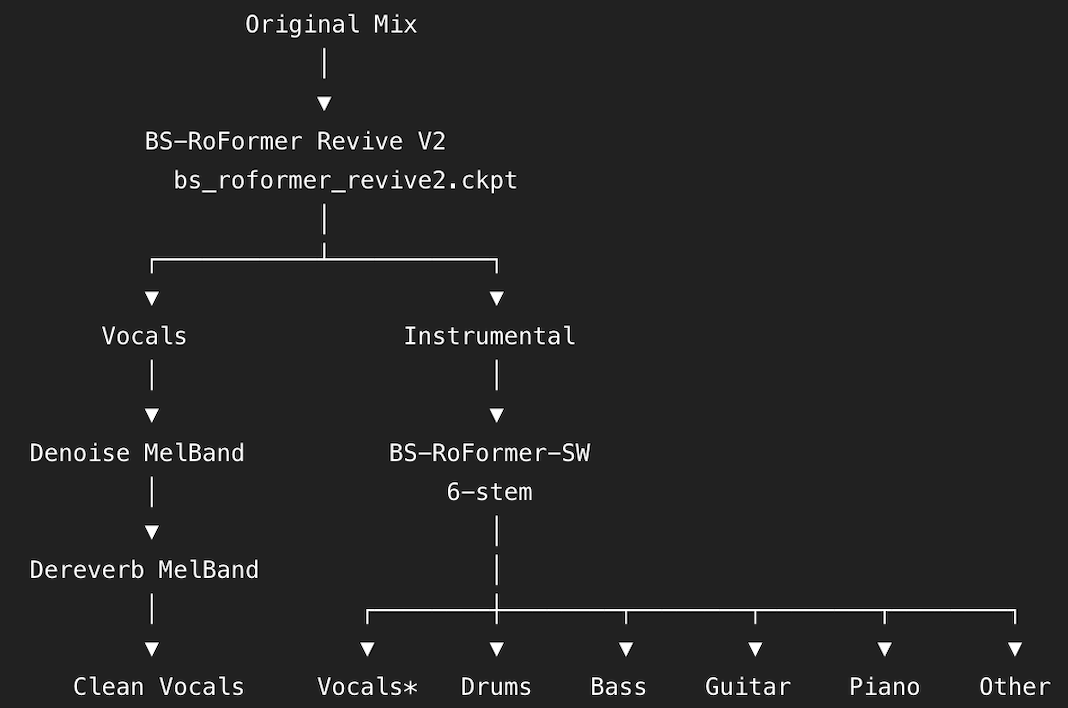


## 0. 作業マシンの変更/確認

**ランタイムのタイプを変更**から **Python3, T4 GPU, 最新Ver.** を選択する。


In [ ]:
!nvidia-smi

import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is unavailable. In Colab, choose Runtime → Change runtime type → GPU and reconnect.")
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM GiB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))


## 1. 依存パッケージのインストール



In [ ]:
!apt-get -qq update
!apt-get -qq install -y ffmpeg
!pip -q install "bs-roformer-infer>=0.1.5" soundfile scipy pyyaml matplotlib

# 実際にインストールされたバージョンを明示的に確認する(仮定で進めない)
!pip show bs-roformer-infer | grep -E "^(Name|Version)"


## 2. 分岐A: `bs_roformer_revive2.ckpt` のダウンロードと検証

制作者本人(unwa氏, HF上のアカウント名は pcunwa)が直接ホストしている一次配布元から取得し、SHA-256を検証します。

In [ ]:
from pathlib import Path
import hashlib
import urllib.request

MODEL_DIR = Path("/content/bs_roformer_revive2")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CKPT = MODEL_DIR / "bs_roformer_revive2.ckpt"
CONFIG = MODEL_DIR / "config.yaml"

CKPT_URL = "https://huggingface.co/pcunwa/BS-Roformer-Revive/resolve/main/bs_roformer_revive2.ckpt"
CONFIG_URL = "https://huggingface.co/pcunwa/BS-Roformer-Revive/resolve/main/config.yaml"
# 2026-08時点でHugging Face上のファイルページに掲載されているSHA-256と一致を確認済み
EXPECTED_SHA256 = "58098850c882a7472dad39f99fb8040ce6eaafe671cfe9881d89aea276bbb5f5"

if not CKPT.exists():
    print("Downloading checkpoint...")
    urllib.request.urlretrieve(CKPT_URL, CKPT)

if not CONFIG.exists():
    print("Downloading config.yaml...")
    urllib.request.urlretrieve(CONFIG_URL, CONFIG)

h = hashlib.sha256()
with CKPT.open("rb") as f:
    for chunk in iter(lambda: f.read(8 * 1024 * 1024), b""):
        h.update(chunk)

actual_sha256 = h.hexdigest()
print("Checkpoint:", CKPT)
print("Config:", CONFIG)
print("SHA-256:", actual_sha256)

if actual_sha256 != EXPECTED_SHA256:
    raise RuntimeError(
        "Checkpoint SHA-256 mismatch. Hugging Face側でファイルが更新された可能性があります。"
        "https://huggingface.co/pcunwa/BS-Roformer-Revive/blob/main/bs_roformer_revive2.ckpt "
        "で現在のSHA-256を目視確認してください。"
    )

print("SHA-256 verification: OK")


## 3. Revive2の元設定を確認

In [ ]:
print(CONFIG.read_text())

## 4. Revive2用の推論設定を構築

- `chunk_size` / `dim_t`: 変更しない(公開されているアーキテクチャ値のまま)
- `num_overlap`: 2 → **4**(音切れ対策)
- `batch_size`: 2(CUDA OOMが出る場合のみ1に下げる)


In [ ]:
import yaml
from bs_roformer.inference import SafeLoaderWithTuple

INFERENCE_BATCH_SIZE = 2
INFERENCE_OVERLAP = 4

with CONFIG.open() as f:
    cfg = yaml.load(f, Loader=SafeLoaderWithTuple)

# Preserve the model architecture exactly as published.
cfg["inference"]["batch_size"] = INFERENCE_BATCH_SIZE
cfg["inference"]["num_overlap"] = INFERENCE_OVERLAP

RUN_CONFIG = MODEL_DIR / "config_colab_improved.yaml"
with RUN_CONFIG.open("w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print("batch_size =", INFERENCE_BATCH_SIZE)
print("num_overlap =", INFERENCE_OVERLAP)
print("runtime config =", RUN_CONFIG)


## 5. 音声のアップロード
32-bit float WAV・44.1kHz・ステレオに変換します。


In [ ]:
from google.colab import files
from pathlib import Path
import subprocess

uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No audio file was uploaded.")

raw_name = next(iter(uploaded))
raw_path = Path("/content") / raw_name

INPUT_DIR = Path("/content/input_wav")
INPUT_DIR.mkdir(exist_ok=True)

# 分岐ごとに出力先を分ける(同じstore_dirに2モデル分の出力を混ぜるとファイル名が衝突し得るため)
OUTPUT_DIR_REVIVE2 = Path("/content/output_revive2_raw")
OUTPUT_DIR_SW = Path("/content/output_sw_raw")
PROCESSED_DIR = Path("/content/output_processed")

OUTPUT_DIR_REVIVE2.mkdir(exist_ok=True)
OUTPUT_DIR_SW.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)

INPUT_WAV = INPUT_DIR / (raw_path.stem + ".wav")

subprocess.run([
    "ffmpeg", "-y", "-i", str(raw_path),
    "-ar", "44100", "-ac", "2", "-c:a", "pcm_f32le", str(INPUT_WAV)
], check=True)

print("Input:", INPUT_WAV)


## 6. 分岐A: BS-Roformer Revive V2 を実行(CUDA)



In [ ]:
import subprocess, sys

cmd = [
    sys.executable, "-m", "bs_roformer.inference",
    "--model_type", "bs_roformer",
    "--config_path", str(RUN_CONFIG),
    "--model_path", str(CKPT),
    "--input_folder", str(INPUT_DIR),
    "--store_dir", str(OUTPUT_DIR_REVIVE2),
    "--device", "cuda:0",
]

print(" ".join(cmd))
subprocess.run(cmd, check=True)


## 7. Revive2の出力を確認


In [ ]:
raw_wavs = sorted(OUTPUT_DIR_REVIVE2.glob("*.wav"))
for p in raw_wavs:
    print(p.name)

if not raw_wavs:
    raise RuntimeError("No output WAV files were produced by Revive2.")


## 8. Instrumentalの残差候補を作成

`instrumental_residual = 元の音源 − 推定ボーカル`


In [ ]:
import numpy as np
import soundfile as sf
from scipy.signal import correlate

def load_audio(path):
    x, sr = sf.read(path, always_2d=True, dtype="float32")
    return x, sr

mix, sr_mix = load_audio(INPUT_WAV)

vocal_candidates = [p for p in raw_wavs if "vocal" in p.name.lower()]
if not vocal_candidates:
    raise RuntimeError("Could not identify a vocals output. Inspect the raw output filenames above.")

VOCALS_WAV = vocal_candidates[0]
vocals, sr_v = load_audio(VOCALS_WAV)

if sr_mix != sr_v:
    raise RuntimeError(f"Sample-rate mismatch: mix={sr_mix}, vocals={sr_v}")

n = min(len(mix), len(vocals))
mix = mix[:n]
vocals = vocals[:n]


def estimate_lag_samples(a, b, sr, max_shift_sec=0.02, window_sec=10.0):
    # 中央付近の数秒を使って a に対する b のサンプルずれを相互相関で推定する。
    # 戻り値が正なら b が a より遅れている。
    a_mono = a.mean(axis=1) if a.ndim > 1 else a
    b_mono = b.mean(axis=1) if b.ndim > 1 else b

    center = len(a_mono) // 2
    half_win = int(min(window_sec * sr, len(a_mono) / 2) // 2)
    seg_a = a_mono[center - half_win: center + half_win]
    seg_b = b_mono[center - half_win: center + half_win]

    max_shift = int(max_shift_sec * sr)
    corr = correlate(seg_a, seg_b, mode="full")
    lags = np.arange(-len(seg_b) + 1, len(seg_a))
    valid = (lags >= -max_shift) & (lags <= max_shift)
    best_lag = int(lags[valid][np.argmax(corr[valid])])
    return best_lag


lag = estimate_lag_samples(mix[:, 0], vocals[:, 0], sr_mix)
print(f"推定サンプルずれ(mixに対するvocalsのずれ): {lag} samples "
      f"({lag / sr_mix * 1000:.3f} ms)")

if lag == 0:
    print("ずれは検出されませんでした。位相干渉によるこもり・音量変動の可能性は低いと考えられます。")
    vocals_aligned = vocals
else:
    print("ずれが検出されました。位相干渉(コムフィルタ)による音質劣化を避けるため、補正してから残差を計算します。")
    if lag > 0:
        vocals_aligned = np.vstack([vocals[lag:], np.zeros((lag, vocals.shape[1]), dtype=vocals.dtype)])
    else:
        shift = -lag
        vocals_aligned = np.vstack([np.zeros((shift, vocals.shape[1]), dtype=vocals.dtype), vocals[:-shift]])

residual = mix - vocals_aligned

RESIDUAL_WAV = PROCESSED_DIR / f"{INPUT_WAV.stem}_instrumental_residual.wav"
sf.write(RESIDUAL_WAV, residual, sr_mix, subtype="FLOAT")

print("Vocals:", VOCALS_WAV)
print("Residual instrumental:", RESIDUAL_WAV)


## 9. 音量変動(pumping)の可視化


In [ ]:
import matplotlib.pyplot as plt

def rms_envelope_db(x, sr, window_sec=1.0):
    x_mono = x.mean(axis=1) if x.ndim > 1 else x
    win = max(int(window_sec * sr), 1)
    n_win = len(x_mono) // win
    env = np.array([
        np.sqrt(np.mean(x_mono[i * win:(i + 1) * win] ** 2) + 1e-12)
        for i in range(n_win)
    ])
    env_db = 20 * np.log10(env + 1e-12)
    t = np.arange(n_win) * window_sec
    return t, env_db

direct_instrumentals_preview = [
    p for p in raw_wavs
    if any(k in p.name.lower() for k in ["instrumental", "other"])
]

plt.figure(figsize=(12, 4))

if direct_instrumentals_preview:
    d, sr_d = load_audio(direct_instrumentals_preview[0])
    t_d, env_d = rms_envelope_db(d, sr_d)
    plt.plot(t_d, env_d, label=f"direct model instrumental ({direct_instrumentals_preview[0].name})")

t_r, env_r = rms_envelope_db(residual, sr_mix)
plt.plot(t_r, env_r, label="residual instrumental (mix - vocals, aligned)")

plt.xlabel("time [s]")
plt.ylabel("RMS level [dBFS] (1s window)")
plt.title("Instrumental level over time — periodic dips may indicate chunk-boundary pumping")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 10. Instrumentalのdenoise(任意)

シンバル・ハイハット・ルームアンビエンスなど高域の情報が重要な場合はOFFのままにしてください。

**デフォルトOFF**


In [ ]:
import subprocess

ENABLE_DENOISE = False #任意
DENOISE_NOISE_FLOOR = -28

DENOISED_WAV = PROCESSED_DIR / f"{INPUT_WAV.stem}_instrumental_residual_denoised.wav"

if ENABLE_DENOISE:
    subprocess.run([
        "ffmpeg", "-y", "-i", str(RESIDUAL_WAV),
        "-af", f"afftdn=nf={DENOISE_NOISE_FLOOR}:tn=1",
        "-c:a", "pcm_f32le", str(DENOISED_WAV)
    ], check=True)
    print("Denoised:", DENOISED_WAV)
else:
    print("Denoise is OFF. Set ENABLE_DENOISE = True and rerun this cell to test it.")


## 11. 音量の波をならす

 `dynaudnorm` 緩やかにゲインを平滑化する仕組みで、通常のコンプレッサーとは異なり急速な音量変化(=pumpingの聴感)を作りにくいとされています。


In [ ]:
import subprocess

ENABLE_LEVEL_SMOOTHING = True #変更可能
DYNAUDNORM_WINDOW_FRAMES = 501

SMOOTHED_WAV = PROCESSED_DIR / f"{INPUT_WAV.stem}_instrumental_residual_smoothed.wav"

_source_for_smoothing = DENOISED_WAV if ENABLE_DENOISE and DENOISED_WAV.exists() else RESIDUAL_WAV

if ENABLE_LEVEL_SMOOTHING:
    subprocess.run([
        "ffmpeg", "-y", "-i", str(_source_for_smoothing),
        "-af", f"dynaudnorm=f={DYNAUDNORM_WINDOW_FRAMES}",
        "-c:a", "pcm_f32le", str(SMOOTHED_WAV)
    ], check=True)
    print("Level-smoothed:", SMOOTHED_WAV)
else:
    print("Level smoothing is OFF. Set ENABLE_LEVEL_SMOOTHING = True and rerun this cell to test it.")


## 12. ピークガード



In [ ]:
import soundfile as sf
import numpy as np

ENABLE_PEAK_GUARD = True
TARGET_PEAK_DBFS = -1.0

if ENABLE_LEVEL_SMOOTHING and SMOOTHED_WAV.exists():
    SOURCE_FOR_EXPORT = SMOOTHED_WAV
elif ENABLE_DENOISE and DENOISED_WAV.exists():
    SOURCE_FOR_EXPORT = DENOISED_WAV
else:
    SOURCE_FOR_EXPORT = RESIDUAL_WAV

EXPORT_WAV = PROCESSED_DIR / f"{INPUT_WAV.stem}_instrumental_final.wav"

audio, sr = sf.read(SOURCE_FOR_EXPORT, always_2d=True, dtype="float32")

if ENABLE_PEAK_GUARD:
    peak = float(np.max(np.abs(audio)))
    target = 10 ** (TARGET_PEAK_DBFS / 20.0)
    if peak > target and peak > 0:
        audio = audio * (target / peak)

sf.write(EXPORT_WAV, audio, sr, subtype="FLOAT")
print("Final instrumental (Revive2 branch):", EXPORT_WAV)


## 13. 分岐B: BS-Roformer-SW(6-stem)のダウンロード


In [ ]:
from bs_roformer import MODEL_REGISTRY

SW_SLUG = "roformer-model-bs-roformer-sw-by-jarredou"
sw_entry = MODEL_REGISTRY.get(SW_SLUG)

print("slug:", sw_entry.slug)
print("checkpoint filename:", sw_entry.checkpoint)
print("config filename:", sw_entry.config)


In [ ]:
import subprocess

SW_MODELS_ROOT = Path("/content/models")
SW_MODEL_DIR = SW_MODELS_ROOT / SW_SLUG

subprocess.run([
    "bs-roformer-download",
    "--model", SW_SLUG,
    "--output-dir", str(SW_MODELS_ROOT),
], check=True)

SW_CKPT = SW_MODEL_DIR / sw_entry.checkpoint
SW_CONFIG = SW_MODEL_DIR / sw_entry.config

if not SW_CKPT.exists() or not SW_CONFIG.exists():
    raise RuntimeError(
        f"想定したパスにファイルが見つかりません。実際のダウンロード先を確認してください: {SW_MODEL_DIR}\n"
        f"中身: {list(SW_MODEL_DIR.glob('*')) if SW_MODEL_DIR.exists() else '(ディレクトリが存在しません)'}"
    )

print("SW checkpoint:", SW_CKPT)
print("SW config:", SW_CONFIG)


## 14. BS-Roformer-SWの元設定を確認


In [ ]:
print(SW_CONFIG.read_text())

## 15. BS-Roformer-SW用の推論設定を構築


In [ ]:
SW_INFERENCE_BATCH_SIZE = 2
SW_INFERENCE_OVERLAP = 4

with SW_CONFIG.open() as f:
    sw_cfg = yaml.load(f, Loader=SafeLoaderWithTuple)

sw_cfg["inference"]["batch_size"] = SW_INFERENCE_BATCH_SIZE
sw_cfg["inference"]["num_overlap"] = SW_INFERENCE_OVERLAP

SW_RUN_CONFIG = SW_MODEL_DIR / "config_colab_improved.yaml"
with SW_RUN_CONFIG.open("w") as f:
    yaml.safe_dump(sw_cfg, f, sort_keys=False)

print("SW batch_size =", SW_INFERENCE_BATCH_SIZE)
print("SW num_overlap =", SW_INFERENCE_OVERLAP)
print("SW runtime config =", SW_RUN_CONFIG)


## 16. BS-Roformer-SWを実行(CUDA)

6-stem(vocals, drums, bass, guitar, piano, other)の分離を行います。


In [ ]:
cmd_sw = [
    sys.executable, "-m", "bs_roformer.inference",
    "--model_type", "bs_roformer",
    "--config_path", str(SW_RUN_CONFIG),
    "--model_path", str(SW_CKPT),
    "--input_folder", str(INPUT_DIR),
    "--store_dir", str(OUTPUT_DIR_SW),
    "--device", "cuda:0",
]

print(" ".join(cmd_sw))
subprocess.run(cmd_sw, check=True)


## 17. BS-Roformer-SWの出力を6-stemに仕分け



In [ ]:
sw_raw_wavs = sorted(OUTPUT_DIR_SW.glob("*.wav"))
print("BS-Roformer-SW raw outputs:")
for p in sw_raw_wavs:
    print(" ", p.name)

if not sw_raw_wavs:
    raise RuntimeError("No output WAV files were produced by BS-Roformer-SW.")

STEM_KEYWORDS = {
    "vocals": ["vocal"],
    "drums": ["drum"],
    "bass": ["bass"],
    "guitar": ["guitar"],
    "piano": ["piano"],
    "other": ["other"],
    "instrumental": ["instrumental"],
}

sw_stems = {}
for stem, keywords in STEM_KEYWORDS.items():
    matches = [p for p in sw_raw_wavs if any(k in p.name.lower() for k in keywords)]
    sw_stems[stem] = matches[0] if matches else None
    status = matches[0].name if matches else "見つかりませんでした"
    print(f"{stem}: {status}")

missing_core = [s for s in ["vocals", "drums", "bass", "guitar", "piano", "other"] if sw_stems[s] is None]
if missing_core:
    print()
    print("警告: 以下のstemが検出できませんでした。ファイル命名規則が想定と異なる可能性があります。")
    print(missing_core)
    print("上に表示された生ファイル名一覧を直接確認し、必要なら STEM_KEYWORDS を調整してください。")


## 18. BS-Roformer-SW出力にピークガードを適用してエクスポート


In [ ]:
SW_EXPORT_DIR = PROCESSED_DIR / "sw_stems"
SW_EXPORT_DIR.mkdir(exist_ok=True)

TARGET_PEAK_DBFS_SW = -1.0

def apply_peak_guard(path, target_dbfs):
    audio, sr = sf.read(path, always_2d=True, dtype="float32")
    peak = float(np.max(np.abs(audio)))
    target = 10 ** (target_dbfs / 20.0)
    if peak > target and peak > 0:
        audio = audio * (target / peak)
    return audio, sr

sw_export_paths = {}
for stem, path in sw_stems.items():
    if path is None:
        continue
    audio, sr = apply_peak_guard(path, TARGET_PEAK_DBFS_SW)
    out_path = SW_EXPORT_DIR / f"{INPUT_WAV.stem}_{stem}_sw_final.wav"
    sf.write(out_path, audio, sr, subtype="FLOAT")
    sw_export_paths[stem] = out_path
    print(f"{stem} ->", out_path)


## 19. 両分岐の結果を表示


In [ ]:
direct_instrumentals = [
    p for p in raw_wavs
    if any(k in p.name.lower() for k in ["instrumental", "other"])
]

print("=== Branch A: BS-Roformer Revive V2 (2-stem) ===")
print("Vocals:", VOCALS_WAV)
print("Direct model instrumental candidates:")
for p in direct_instrumentals:
    print(" ", p)
print("Residual instrumental (aligned):", RESIDUAL_WAV)
print("Final processed instrumental:", EXPORT_WAV)

print()
print("=== Branch B: BS-Roformer-SW (6-stem) ===")
for stem, path in sw_export_paths.items():
    print(f"{stem}:", path)


## 20. ファイルのダウンロード


In [ ]:
from google.colab import files

download_list = [VOCALS_WAV, RESIDUAL_WAV, EXPORT_WAV] + direct_instrumentals + list(sw_export_paths.values())
seen = set()

for p in download_list:
    if p is None:
        continue
    key = str(p)
    if not p.exists() or key in seen:
        continue
    seen.add(key)
    print("Downloading:", p.name)
    files.download(str(p))


`(音源ファイル)_instrumental_final.wav` :
RESIDUAL_WAV に対して、必要に応じてノイズ除去（denoise）や音量平滑化（level smoothing）が適用され、最終的にピークガード処理が行われた楽器トラックです。